In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('shark_tank.csv')
data.shape

(290, 64)

In [ ]:
data.head()

,Season Number,Season Start,Season End,Episode Number,Episode Title,Pitch Number,Startup Name,Industry,Business Description,Company Website,...,Ghazal Investment Amount,Ghazal Investment Equity,Ghazal Debt Amount,Amit Investment Amount,Amit Investment Equity,Amit Debt Amount,Guest Investment Amount,Guest Investment Equity,Guest Debt Amount,Guest Name
0,1,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,1,BluePineFoods,Food,Frozen Momos,https://bluepinefoods.com/,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,2,BoozScooters,Vehicles/Electrical Vehicles,Renting e-bike for mobility in private spaces,https://www.boozup.net/,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,3,HeartUpMySleeves,Beauty/Fashion,Detachable Sleeves,https://heartupmysleeves.com/,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,20-Dec-21,04-Feb-22,2,"Insaan, Ideas Aur Sapne",4,TagzFoods,Food,Healthy Potato Chips Snacks,https://tagzfoods.com/,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,20-Dec-21,04-Feb-22,2,"Insaan, Ideas Aur Sapne",5,HeadAndHeart,Education,Brain Development Course,https://thehnh.in/,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 64 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season Number              290 non-null    int64  
 1   Season Start               290 non-null    object 
 2   Season End                 290 non-null    object 
 3   Episode Number             290 non-null    int64  
 4   Episode Title              290 non-null    object 
 5   Pitch Number               290 non-null    int64  
 6   Startup Name               290 non-null    object 
 7   Industry                   290 non-null    object 
 8   Business Description       290 non-null    object 
 9   Company Website            281 non-null    object 
 10  Number of Presenters       290 non-null    int64  
 11  Male Presenters            253 non-null    float64
 12  Female Presenters          133 non-null    float64
 13  Transgender Presenters     1 non-null      float64

In [ ]:
data.isna().sum()

,0
Season Number,0
Season Start,0
Season End,0
Episode Number,0
Episode Title,0
...,...
Amit Debt Amount,286
Guest Investment Amount,288
Guest Investment Equity,288
Guest Debt Amount,288


In [ ]:
for val in data.columns:
    data.rename(columns={val:val.lower().replace(" ","_")},inplace=True)
data.columns


Index(['season_number', 'season_start', 'season_end', 'episode_number',
       'episode_title', 'pitch_number', 'startup_name', 'industry',
       'business_description', 'company_website', 'number_of_presenters',
       'male_presenters', 'female_presenters', 'transgender_presenters',
       'couple_presenters', 'pitchers_average_age', 'started_in',
       'pitchers_city', 'pitchers_state', 'yearly_revenue', 'monthly_sales',
       'gross_margin', 'net_margin', 'original_ask_amount',
       'original_offered_equity', 'valuation_requested', 'received_offer',
       'accepted_offer', 'total_deal_amount', 'total_deal_equity',
       'total_deal_debt', 'debt_interest', 'deal_valuation',
       'number_of_sharks_in_deal', 'deal_has_conditions', 'has_patents',
       'ashneer_investment_amount', 'ashneer_investment_equity',
       'ashneer_debt_amount', 'namita_investment_amount',
       'namita_investment_equity', 'namita_debt_amount',
       'anupam_investment_amount', 'anupam_investment_

In [ ]:
object_df = data.select_dtypes(include='object')
object_df[object_df.columns[object_df.isna().sum()>0]].isna().sum()

,0
company_website,9
deal_has_conditions,282
guest_name,288


In [ ]:
data["deal_has_conditions"].fillna("No",inplace=True)
data["deal_has_conditions"].isna().sum()

np.int64(0)

In [ ]:
data["deal_has_conditions"] = data["deal_has_conditions"].str.lower()

In [ ]:
data.drop(columns=["company_website"],inplace=True)

In [ ]:
data.select_dtypes("number").isna().sum()

,0
season_number,0
episode_number,0
pitch_number,0
number_of_presenters,0
male_presenters,37
female_presenters,157
transgender_presenters,289
couple_presenters,3
started_in,127
yearly_revenue,164


In [ ]:

data["season_start"]=pd.to_datetime(data["season_start"],format="%d-%b-%y")
data["season_end"] =pd.to_datetime(data["season_end"],format="%d-%b-%y")

In [ ]:
for col in data.select_dtypes("number"):
  data[col] = data[col].fillna(0)
  try :
    data[col] = data.astype(int)
  except :
    data[col] = data[col].astype(float)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 63 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   season_number              290 non-null    float64       
 1   season_start               290 non-null    datetime64[ns]
 2   season_end                 290 non-null    datetime64[ns]
 3   episode_number             290 non-null    float64       
 4   episode_title              290 non-null    object        
 5   pitch_number               290 non-null    float64       
 6   startup_name               290 non-null    object        
 7   industry                   290 non-null    object        
 8   business_description       290 non-null    object        
 9   number_of_presenters       290 non-null    float64       
 10  male_presenters            290 non-null    float64       
 11  female_presenters          290 non-null    float64       
 12  transgen

In [ ]:
data['guest_name'] = data.guest_name.fillna("Not present")

In [ ]:
data.isna().sum().sum()

np.int64(0)

In [ ]:
data

,season_number,season_start,season_end,episode_number,episode_title,pitch_number,startup_name,industry,business_description,number_of_presenters,...,ghazal_investment_amount,ghazal_investment_equity,ghazal_debt_amount,amit_investment_amount,amit_investment_equity,amit_debt_amount,guest_investment_amount,guest_investment_equity,guest_debt_amount,guest_name
0,1.0,2021-12-20,2022-02-04,1.0,Badlegi Business Ki Tasveer,1.0,BluePineFoods,Food,Frozen Momos,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Not present
1,1.0,2021-12-20,2022-02-04,1.0,Badlegi Business Ki Tasveer,2.0,BoozScooters,Vehicles/Electrical Vehicles,Renting e-bike for mobility in private spaces,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Not present
2,1.0,2021-12-20,2022-02-04,1.0,Badlegi Business Ki Tasveer,3.0,HeartUpMySleeves,Beauty/Fashion,Detachable Sleeves,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Not present
3,1.0,2021-12-20,2022-02-04,2.0,"Insaan, Ideas Aur Sapne",4.0,TagzFoods,Food,Healthy Potato Chips Snacks,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Not present
4,1.0,2021-12-20,2022-02-04,2.0,"Insaan, Ideas Aur Sapne",5.0,HeadAndHeart,Education,Brain Development Course,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Not present
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,2.0,2023-01-02,2023-03-10,50.0,Season Finale With The Sharks,316.0,MYBYK,Vehicles/Electrical Vehicles,IoT-enabled bikes,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Not present
286,2.0,2023-01-02,2023-03-10,51.0,Gateway To Shark Tank India,317.0,GODESi,Food,Handmade lollipops,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Not present
287,2.0,2023-01-02,2023-03-10,51.0,Gateway To Shark Tank India,318.0,TAC,Beauty/Fashion,"ayurveda co for glowing skin, makeup & open pores",2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,40.5,0.5,34.5,Vikas
288,2.0,2023-01-02,2023-03-10,51.0,Gateway To Shark Tank India,319.0,Naara-Aaba,Liquor/Beverages,pears and plum wine,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,25.0,2.5,12.5,Vikas


Analysis


In [ ]:
for col in data.columns:
  print(f"{col} : {data[col].nunique()}")

season_number : 2
season_start : 2
season_end : 2
episode_number : 51
episode_title : 86
pitch_number : 290
startup_name : 290
industry : 16
business_description : 289
number_of_presenters : 6
male_presenters : 7
female_presenters : 4
transgender_presenters : 2
couple_presenters : 2
pitchers_average_age : 3
started_in : 15
pitchers_city : 77
pitchers_state : 34
yearly_revenue : 67
monthly_sales : 69
gross_margin : 37
net_margin : 18
original_ask_amount : 34
original_offered_equity : 27
valuation_requested : 78
received_offer : 2
accepted_offer : 2
total_deal_amount : 33
total_deal_equity : 43
total_deal_debt : 17
debt_interest : 4
deal_valuation : 79
number_of_sharks_in_deal : 6
deal_has_conditions : 2
has_patents : 2
ashneer_investment_amount : 10
ashneer_investment_equity : 15
ashneer_debt_amount : 3
namita_investment_amount : 30
namita_investment_equity : 31
namita_debt_amount : 10
anupam_investment_amount : 24
anupam_investment_equity : 32
anupam_debt_amount : 5
vineeta_investment_

In [54]:
orange = "#FE7743"
blue = "#273F4F"
white = "#D7D7D7"
sky = "#447D9B"
def show(ax):
  ax.set_facecolor(blue)
  plt.gcf().set_facecolor(blue)
  ax.title.set_color(white)
  ax.xaxis.label.set_color(white)
  ax.yaxis.label.set_color(white)
  ax.tick_params(colors=white)
  for spine in ax.spines.values():
    spine.set_edgecolor(white)



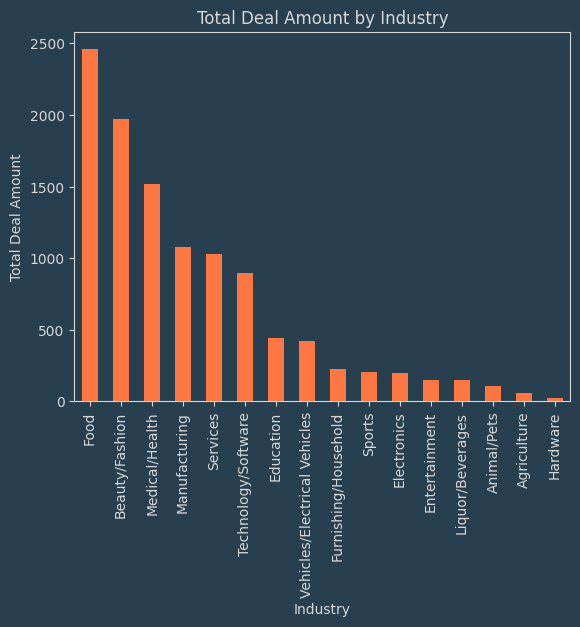

In [55]:
ax = data.groupby("industry")["total_deal_amount"].sum().sort_values(ascending=False).plot(
    kind="bar", color=orange)
plt.title("Total Deal Amount by Industry")
plt.xlabel("Industry")
plt.ylabel("Total Deal Amount")
show(ax)

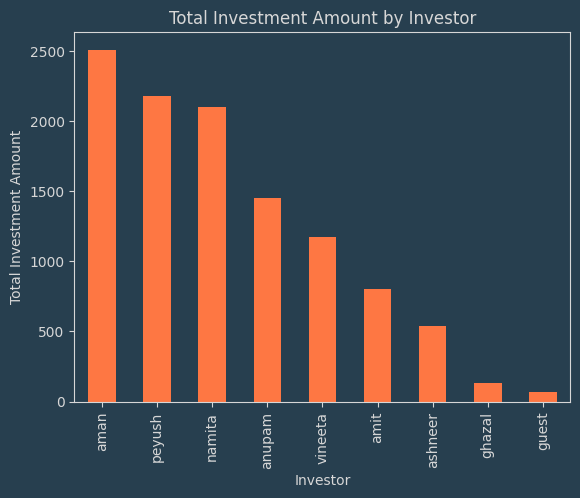

In [ ]:
inv_columns = [col for col in data.columns if "investment_amount" in col.lower()]
inv_data = data[inv_columns].sum()
inv_index = [val.split("_")[0] for val in inv_data.index]
inv_data.index = inv_index
inv_data = inv_data.sort_values(ascending=False)
ax = inv_data.plot(kind="bar",color=orange)
plt.title("Total Investment Amount by Investor")
plt.xlabel("Investor")
plt.ylabel("Total Investment Amount")
show(ax)

In [ ]:
episode_col = ['season_number', 'season_start', 'season_end', 'episode_number', 'episode_title', 'pitch_number']
startup_col = ['startup_name', 'industry',
       'business_description', 'number_of_presenters', 'male_presenters',
       'female_presenters', 'transgender_presenters', 'couple_presenters',
       'pitchers_average_age', 'started_in', 'pitchers_city', 'pitchers_state']
numbers_col = ['yearly_revenue', 'monthly_sales', 'gross_margin', 'net_margin',
       'original_ask_amount', 'original_offered_equity', 'valuation_requested',
       'received_offer', 'accepted_offer', 'total_deal_amount',
       'total_deal_equity', 'total_deal_debt', 'debt_interest',
       'deal_valuation', 'number_of_sharks_in_deal', 'deal_has_conditions',
       'has_patents']
shark_col = ['ashneer_investment_amount', 'ashneer_investment_equity',
       'ashneer_debt_amount', 'namita_investment_amount',
       'namita_investment_equity', 'namita_debt_amount',
       'anupam_investment_amount', 'anupam_investment_equity',
       'anupam_debt_amount', 'vineeta_investment_amount',
       'vineeta_investment_equity', 'vineeta_debt_amount',
       'aman_investment_amount', 'aman_investment_equity', 'aman_debt_amount',
       'peyush_investment_amount', 'peyush_investment_equity',
       'peyush_debt_amount', 'ghazal_investment_amount',
       'ghazal_investment_equity', 'ghazal_debt_amount',
       'amit_investment_amount', 'amit_investment_equity', 'amit_debt_amount',
       'guest_investment_amount', 'guest_investment_equity',
       'guest_debt_amount', 'guest_name']

In [ ]:
inv_col = []
debt_col = []
equity_col = []
for col in shark_col[:]:
  if "investment_amount" in col:
    inv_col.append(col)
    shark_col.remove(col)
  elif "debt_amount" in col:
    debt_col.append(col)
    shark_col.remove(col)
  elif "equity" in  col:
    equity_col.append(col)
    shark_col.remove(col)
print(inv_col)
print(debt_col)
print(equity_col)
print(shark_col)

['ashneer_investment_amount', 'namita_investment_amount', 'anupam_investment_amount', 'vineeta_investment_amount', 'aman_investment_amount', 'peyush_investment_amount', 'ghazal_investment_amount', 'amit_investment_amount', 'guest_investment_amount']
['ashneer_debt_amount', 'namita_debt_amount', 'anupam_debt_amount', 'vineeta_debt_amount', 'aman_debt_amount', 'peyush_debt_amount', 'ghazal_debt_amount', 'amit_debt_amount', 'guest_debt_amount']
['ashneer_investment_equity', 'namita_investment_equity', 'anupam_investment_equity', 'vineeta_investment_equity', 'aman_investment_equity', 'peyush_investment_equity', 'ghazal_investment_equity', 'amit_investment_equity', 'guest_investment_equity']
['guest_name']


In [ ]:
inv_sum = data[inv_col].sum(axis=1)
mismatch_rows = data[inv_sum != data['total_deal_amount']]
mismatch_rows["total_deal_amount"],inv_sum[inv_sum.index.isin(mismatch_rows.index)]

(28      25.00000
 36      40.00000
 45       0.00005
 65     100.00000
 89     100.00000
 91      50.00000
 138    100.00000
 186    100.00000
 193    100.00000
 210    106.00000
 225     80.00000
 228    200.00000
 243     50.00000
 276    100.00000
 Name: total_deal_amount, dtype: float64,
 28      24.990000
 36      39.990000
 45       0.000048
 65      99.990000
 89      99.990000
 91      49.980000
 138     99.990000
 186     99.990000
 193     99.990000
 210    105.980000
 225     79.980000
 228    199.980000
 243     49.980000
 276     99.990000
 dtype: float64)

In [ ]:
data["number_of_sharks_in_deal"].value_counts()

,count
number_of_sharks_in_deal,
0.0,115
1.0,74
2.0,53
3.0,28
4.0,12
5.0,8


In [43]:
data[data['number_of_sharks_in_deal'] == 5][startup_col[:4]+["total_deal_amount","total_deal_equity"]]

,startup_name,industry,business_description,number_of_presenters,total_deal_amount,total_deal_equity
15,SkippiIcePops,Food,Ice-Pops,2.0,100.0,15.0
50,FindYourKicksIndia,Beauty/Fashion,Sneaker Resale,3.0,50.0,25.0
64,INACAN,Food,Can Cocktails,3.0,100.0,10.0
80,SunfoxTechnologies,Medical/Health,Portable ECG Device,4.0,100.0,6.0
179,Snitch,Beauty/Fashion,Menswear,1.0,150.0,1.5
209,Mahantam,Manufacturing,Tea Glass Washing Machine,2.0,30.0,20.0
244,Pharmallama,Medical/Health,Simplified pharmacy,3.0,200.0,5.0
281,Sahayatha,Medical/Health,smart wheelchair with an assistive cleansing d...,1.0,100.0,10.0


In [ ]:
100/1.5 * 150

10000.0

In [ ]:
def get_investors(row):
    inv = ', '.join([col.split('_')[0].capitalize() for col in inv_col if row[col] > 0])
    if inv == "":
      return "None"
    return inv

data['investors'] = data.apply(get_investors, axis=1)


In [ ]:
data.investors.value_counts()

,count
investors,
None,116
Namita,20
Peyush,14
Aman,12
"Aman, Peyush",11
Amit,11
Anupam,8
"Namita, Aman",7
"Anupam, Vineeta",6


In [ ]:
data[data.valuation_requested<data.deal_valuation][startup_col+["valuation_requested","deal_valuation","number_of_sharks_in_deal","investors"]]

,startup_name,industry,business_description,number_of_presenters,male_presenters,female_presenters,transgender_presenters,couple_presenters,pitchers_average_age,started_in,pitchers_city,pitchers_state,valuation_requested,deal_valuation,number_of_sharks_in_deal,investors
10,JhaJiAchaar,Food,Pickle,2.0,0.0,2.0,0.0,0.0,Old,2021.0,Darbhanga,Bihar,500.0,1007.0,2.0,"Namita, Vineeta"


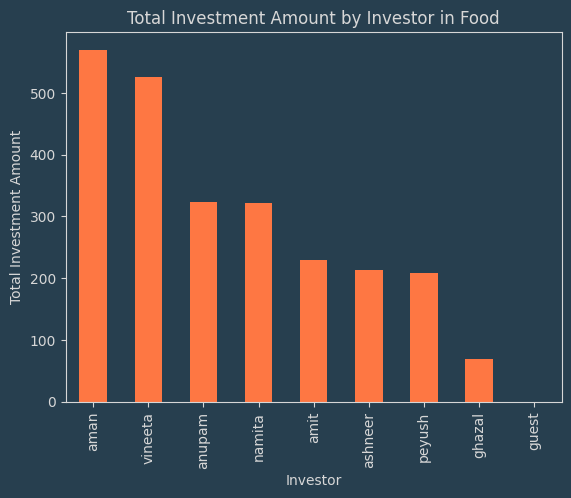

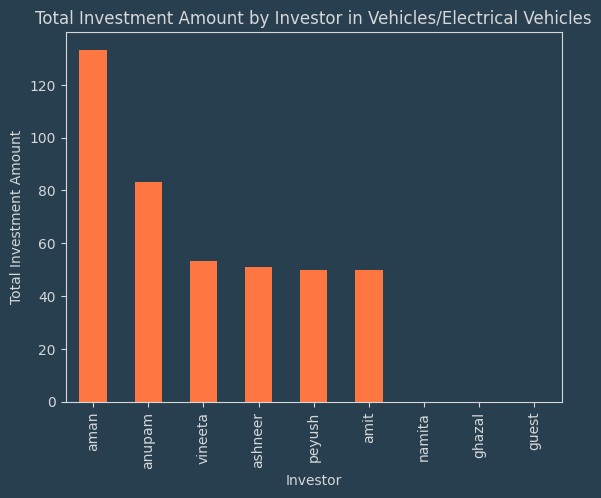

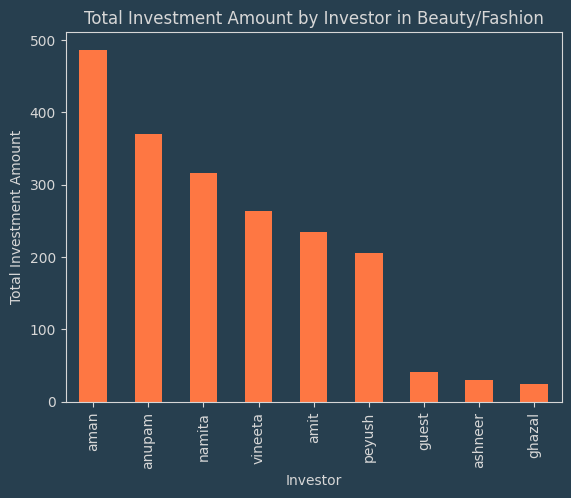

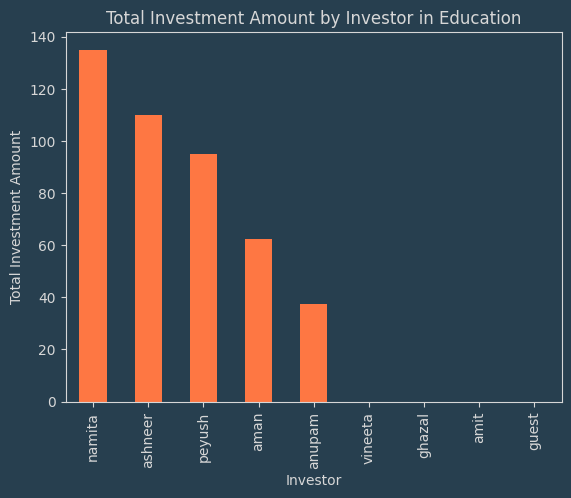

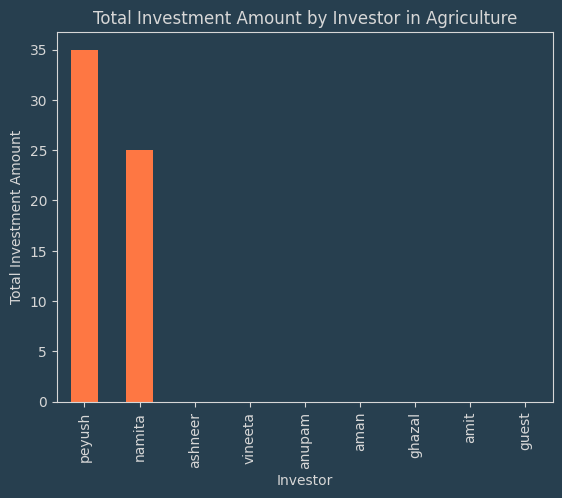

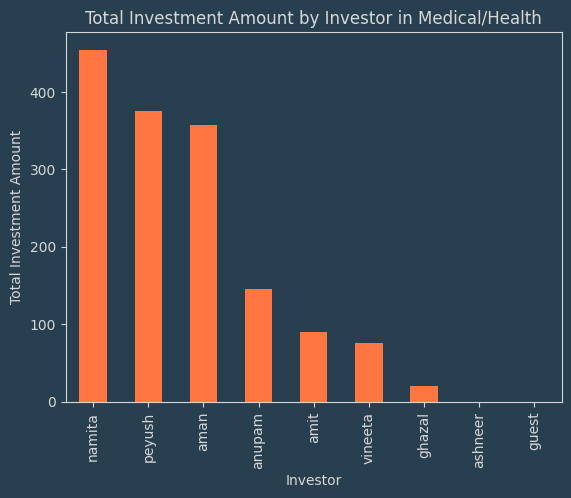

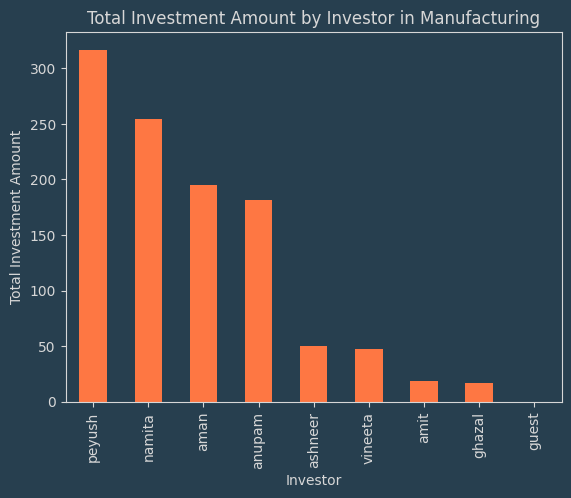

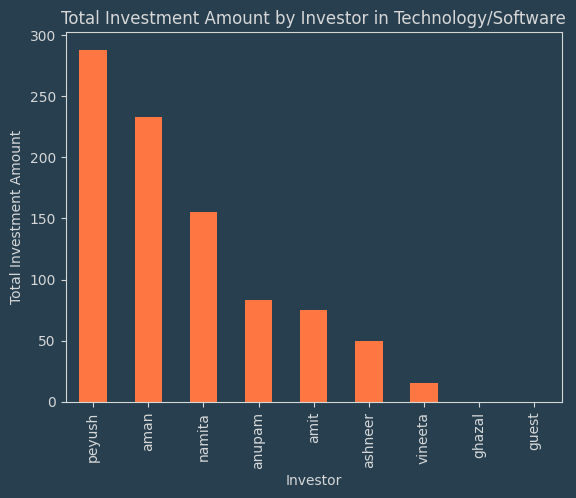

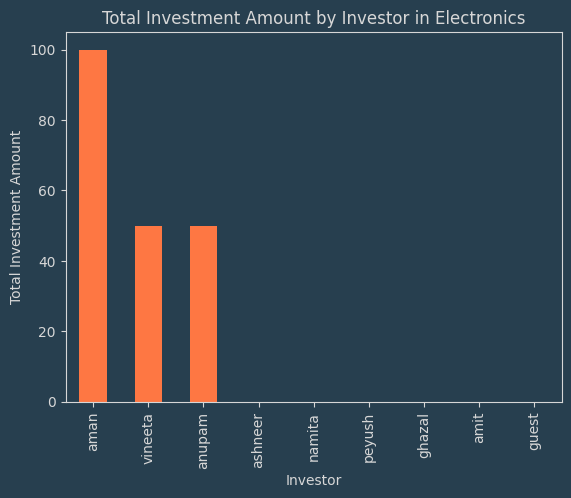

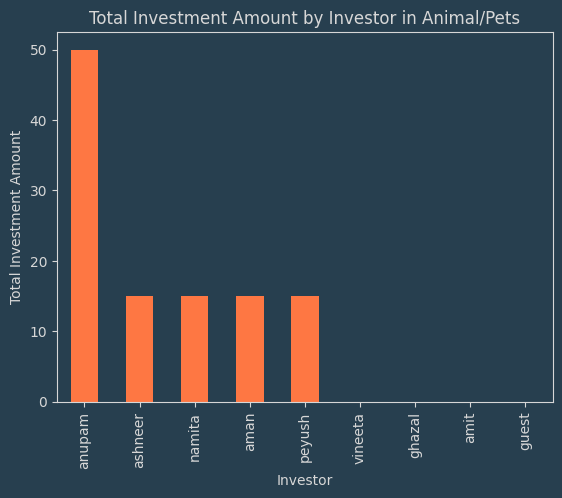

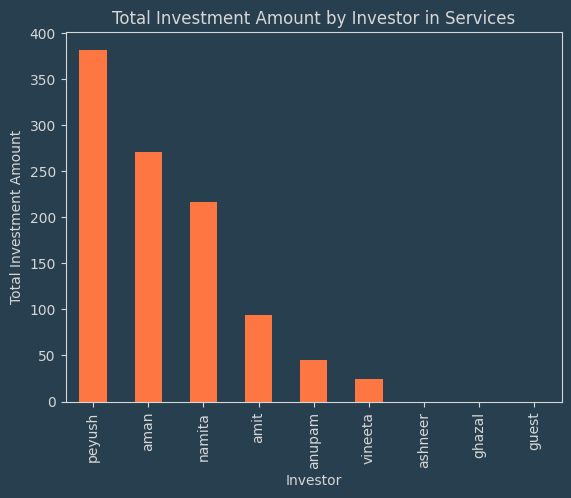

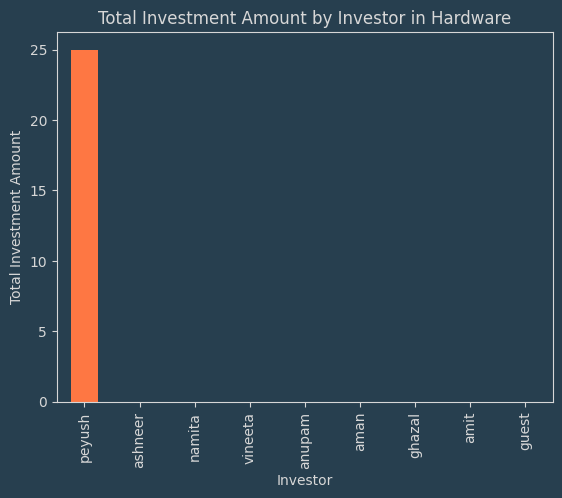

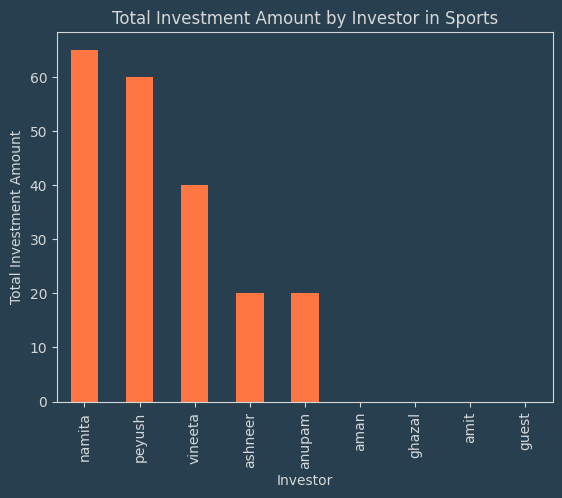

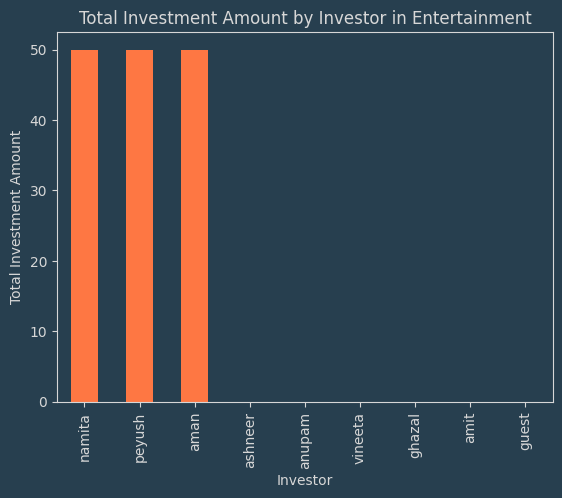

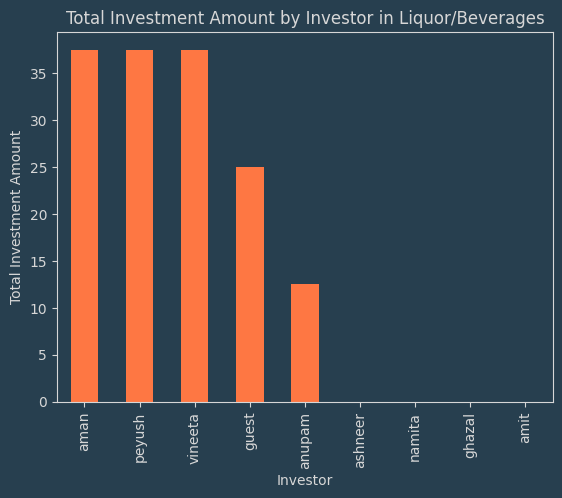

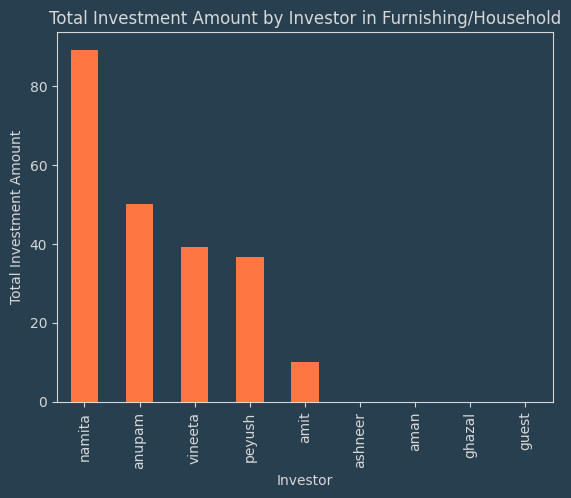

In [ ]:
for val in data['industry'].unique():
  temp = data[data['industry']==val]
  inv_data = temp[inv_columns].sum()
  inv_index = [val.split("_")[0] for val in inv_data.index]
  inv_data.index = inv_index
  inv_data = inv_data.sort_values(ascending=False)
  ax = inv_data.plot(kind="bar",color=orange)
  plt.title(f"Total Investment Amount by Investor in {val}")
  plt.xlabel("Investor")
  plt.ylabel("Total Investment Amount")
  show(ax)

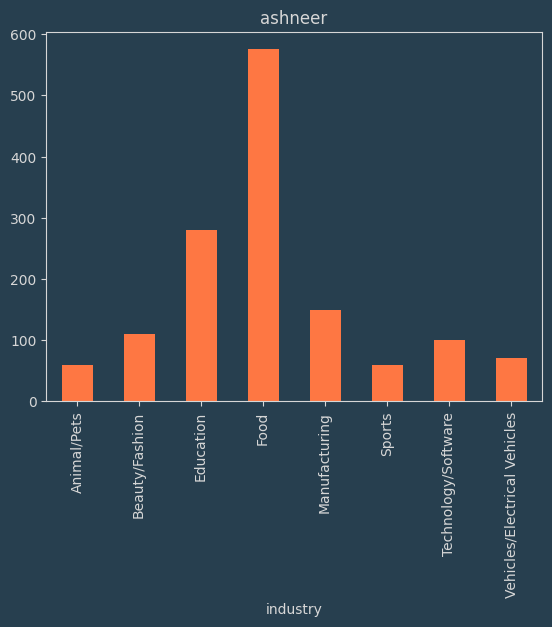

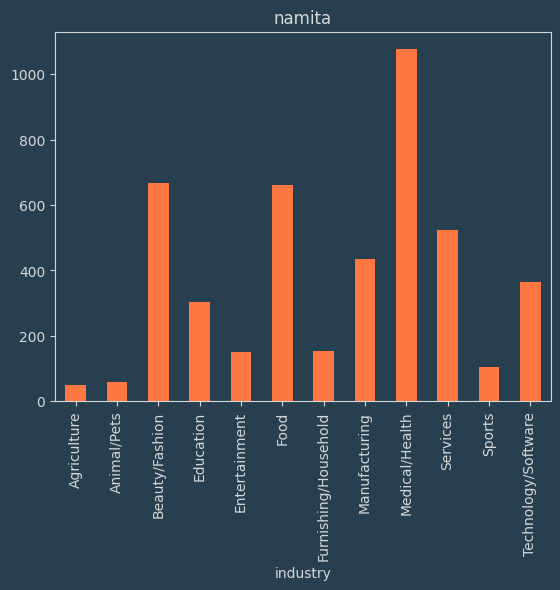

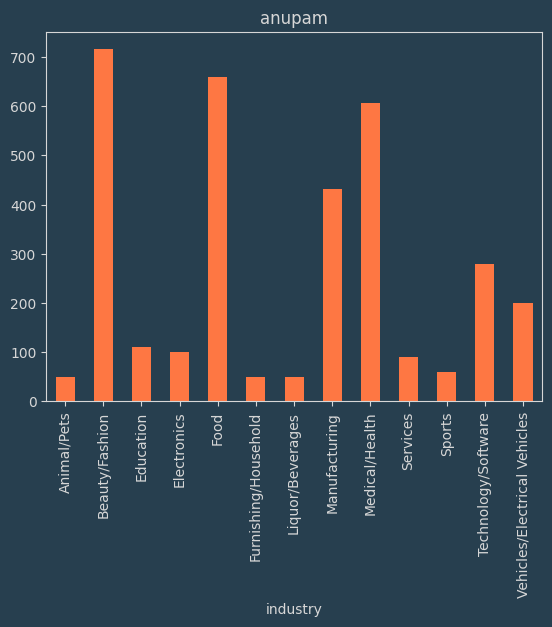

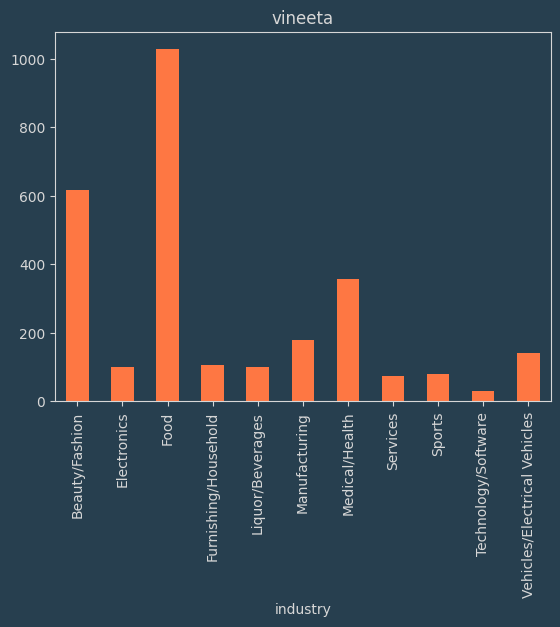

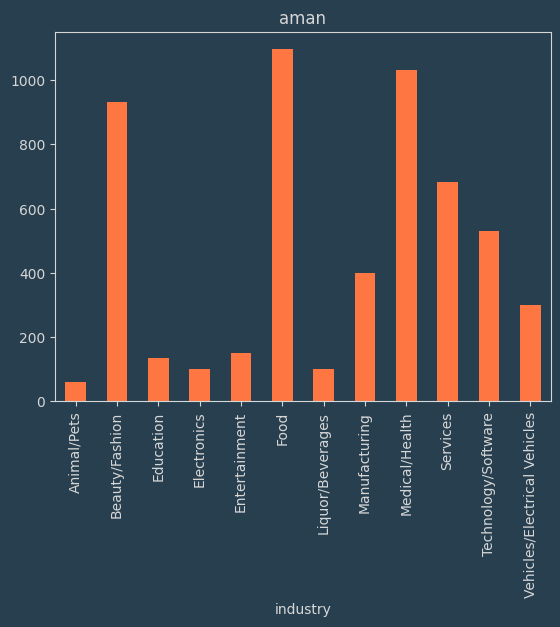

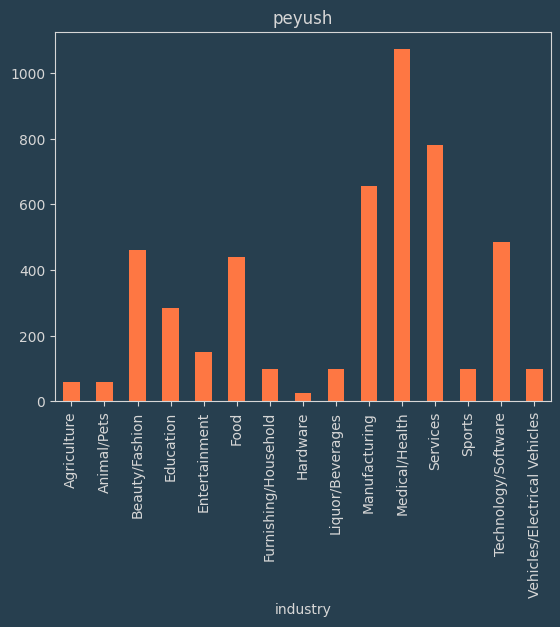

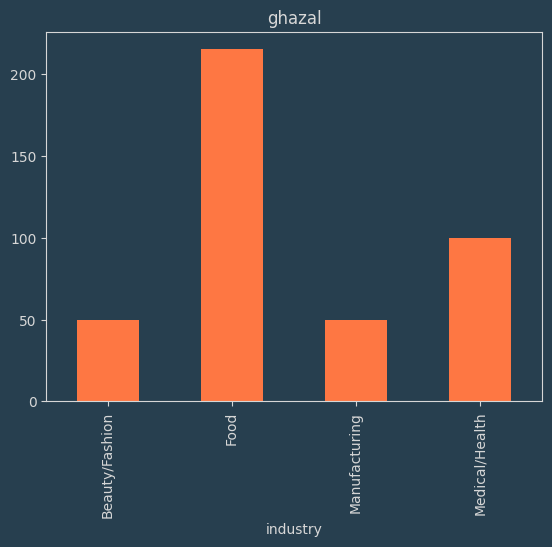

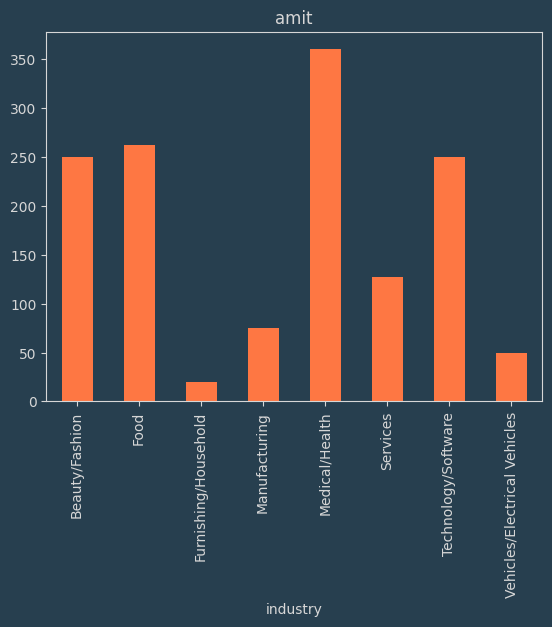

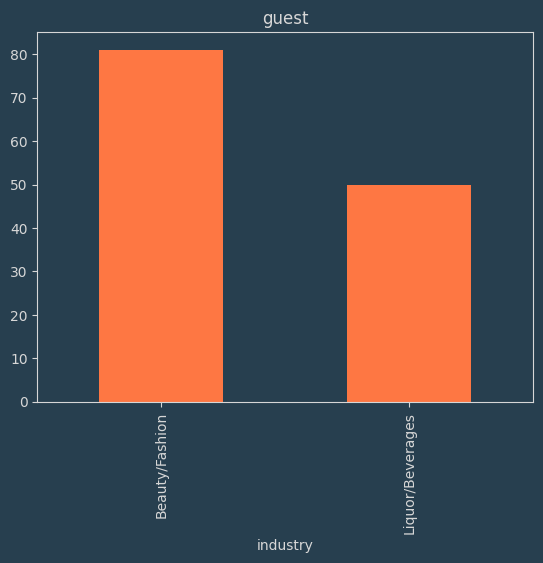

In [56]:
for col in inv_col:
  show(data[data[col]>0].groupby("industry").agg({"total_deal_amount":"sum"}).plot(kind="bar",color=orange,legend=False,title=col.split("_")[0]))
  plt.savefig(col.split("_")[0]+"investment_trend")

In [ ]:
for ind in data.industry.unique():
  temp = data[data.industry==ind]
  success_rate = temp.accepted_offer.sum()/temp.accepted_offer.count() *100
  print(f"Success rate of {ind} is {round(success_rate,2)}% for {temp.accepted_offer.count()} pitches")

Success rate of Food is 56.41% for 78 pitches
Success rate of Vehicles/Electrical Vehicles is 66.67% for 12 pitches
Success rate of Beauty/Fashion is 65.38% for 52 pitches
Success rate of Education is 66.67% for 9 pitches
Success rate of Agriculture is 66.67% for 3 pitches
Success rate of Medical/Health is 85.71% for 21 pitches
Success rate of Manufacturing is 57.58% for 33 pitches
Success rate of Technology/Software is 56.0% for 25 pitches
Success rate of Electronics is 100.0% for 2 pitches
Success rate of Animal/Pets is 50.0% for 4 pitches
Success rate of Services is 54.55% for 22 pitches
Success rate of Hardware is 50.0% for 2 pitches
Success rate of Sports is 57.14% for 7 pitches
Success rate of Entertainment is 100.0% for 1 pitches
Success rate of Liquor/Beverages is 50.0% for 6 pitches
Success rate of Furnishing/Household is 38.46% for 13 pitches


In [ ]:
data[data.industry=="Entertainment"]

,season_number,season_start,season_end,episode_number,episode_title,pitch_number,startup_name,industry,business_description,number_of_presenters,...,ghazal_investment_equity,ghazal_debt_amount,amit_investment_amount,amit_investment_equity,amit_debt_amount,guest_investment_amount,guest_investment_equity,guest_debt_amount,guest_name,investors
129,2.0,2023-01-02,2023-03-10,3.0,Thrilling and Thunderous Pitches,160.0,Stage,Entertainment,Web series and movies in Indian languages,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Not present,"Namita, Aman, Peyush"


In [ ]:
print("Offer Acceptance Rate",round(data.accepted_offer.sum()/data.received_offer.sum()*100,2),"%")

Offer Acceptance Rate 83.33 %


In [ ]:
print(f"Avg valuation requested of accepted offers {round(data[data['total_deal_amount']>0].valuation_requested.mean(),2)}")
print(f"Avg valuation requested of rejected offers {round(data[data['total_deal_amount']==0].valuation_requested.mean(),2)}")
print(f"Avg valuation of final deals {round(data[data['total_deal_amount']>0].deal_valuation.mean(),2)}")

Avg valuation requested of accepted offers 4432.45
Avg valuation requested of rejected offers 6599.12
Avg valuation of final deals 1799.83


In [42]:
data.groupby("pitchers_city")["accepted_offer"].sum().sort_values(ascending=False).head(10)


,accepted_offer
pitchers_city,
Mumbai,27.0
Delhi,25.0
Bangalore,17.0
Pune,13.0
Ahmedabad,11.0
Gurgaon,7.0
Hyderabad,7.0
Kolkata,6.0
Noida,4.0


In [ ]:
data.columns

Index(['season_number', 'season_start', 'season_end', 'episode_number',
       'episode_title', 'pitch_number', 'startup_name', 'industry',
       'business_description', 'number_of_presenters', 'male_presenters',
       'female_presenters', 'transgender_presenters', 'couple_presenters',
       'pitchers_average_age', 'started_in', 'pitchers_city', 'pitchers_state',
       'yearly_revenue', 'monthly_sales', 'gross_margin', 'net_margin',
       'original_ask_amount', 'original_offered_equity', 'valuation_requested',
       'received_offer', 'accepted_offer', 'total_deal_amount',
       'total_deal_equity', 'total_deal_debt', 'debt_interest',
       'deal_valuation', 'number_of_sharks_in_deal', 'deal_has_conditions',
       'has_patents', 'ashneer_investment_amount', 'ashneer_investment_equity',
       'ashneer_debt_amount', 'namita_investment_amount',
       'namita_investment_equity', 'namita_debt_amount',
       'anupam_investment_amount', 'anupam_investment_equity',
       'anupam_de

In [41]:
data[data.startup_name == "JhaJiAchaar"][numbers_col]

,yearly_revenue,monthly_sales,gross_margin,net_margin,original_ask_amount,original_offered_equity,valuation_requested,received_offer,accepted_offer,total_deal_amount,total_deal_equity,total_deal_debt,debt_interest,deal_valuation,number_of_sharks_in_deal,deal_has_conditions,has_patents
10,0.0,5.0,18.0,0.0,50.0,10.0,500.0,1.0,1.0,56.6,5.62,0.0,0.0,1007.0,2.0,no,0.0


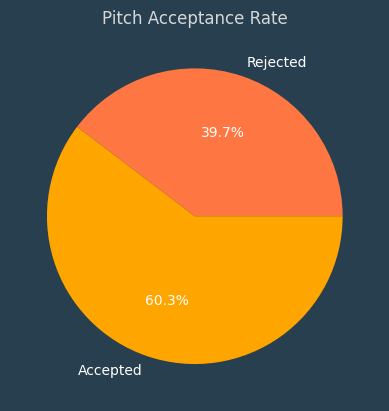

In [84]:
show(data.groupby('accepted_offer').startup_name.count().plot(kind='pie',autopct='%1.1f%%',colors=[orange, 'orange'],
    labels=['Rejected', 'Accepted'],textprops={'color': "white"}
))
plt.title("Pitch Acceptance Rate")
plt.ylabel('')
plt.show()

In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 64 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   season_number              290 non-null    float64       
 1   season_start               290 non-null    datetime64[ns]
 2   season_end                 290 non-null    datetime64[ns]
 3   episode_number             290 non-null    float64       
 4   episode_title              290 non-null    object        
 5   pitch_number               290 non-null    float64       
 6   startup_name               290 non-null    object        
 7   industry                   290 non-null    object        
 8   business_description       290 non-null    object        
 9   number_of_presenters       290 non-null    float64       
 10  male_presenters            290 non-null    float64       
 11  female_presenters          290 non-null    float64       
 12  transgen

In [92]:
data.to_csv("shark_tank_cleaned.csv")